# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
309,-0.009147,0.050680,0.001339,-0.002228,0.079612,0.070084,0.033914,-0.002592,0.026717,0.081764,142.0
413,-0.052738,-0.044642,-0.000817,-0.026328,0.010815,0.007141,0.048640,-0.039493,-0.035816,0.019633,113.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
255,0.001751,-0.044642,-0.065486,-0.005670,-0.007073,-0.019476,0.041277,-0.039493,-0.003301,0.007207,153.0
325,-0.001882,-0.044642,0.054152,-0.066506,0.072732,0.056619,-0.043401,0.084863,0.084492,0.048628,192.0
222,-0.023677,0.050680,-0.025607,0.042529,-0.053855,-0.047660,-0.021311,-0.039493,0.001148,0.019633,252.0
433,-0.027310,-0.044642,-0.060097,-0.029770,0.046589,0.019980,0.122273,-0.039493,-0.051404,-0.009362,72.0
74,0.012648,0.050680,0.002417,0.056301,0.027326,0.017162,0.041277,-0.039493,0.003709,0.073480,85.0
34,0.016281,-0.044642,-0.063330,-0.057313,-0.057983,-0.048912,0.008142,-0.039493,-0.059471,-0.067351,65.0
212,0.067136,-0.044642,0.003494,0.035644,0.049341,0.031254,0.070730,-0.039493,-0.000612,0.019633,73.0


In [10]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan
data.isnull().sum()

data['bmi'] = data['bmi'].fillna(data['bmi'].mean())
data.isnull().sum()

from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

data[['bmi', 'bp']] = imputer.fit_transform(data[['bmi', 'bp']])


,bmi,bp
count,442.000000,442.000000
mean,-0.000205,-0.000074
std,0.044583,0.046442
min,-0.089197,-0.112399
25%,-0.030996,-0.033213
50%,-0.000817,-0.005670
75%,0.024781,0.033053
max,0.160855,0.132044


# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [ ]:
bmi       44
bp        44

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [ ]:
data['bmi'] = data['bmi'].fillna(data['bmi'].mean())

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

data[['bmi', 'bp']] = imputer.fit_transform(data[['bmi', 'bp']])
data[['bmi', 'bp']].describe()

### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

In [12]:
data_original = data.copy()
data['bmi'] = data['bmi'].fillna(data['bmi'].mean())

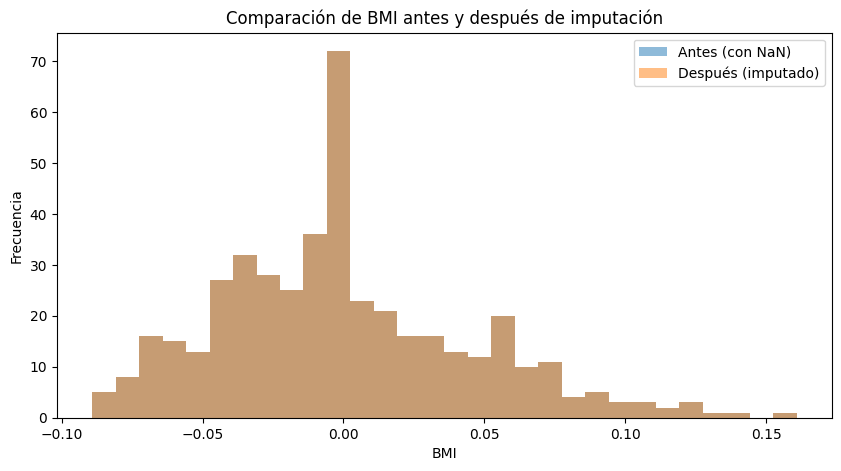

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Antes de imputación
plt.hist(data_original['bmi'], bins=30, alpha=0.5, label='Antes (con NaN)')

# Después de imputación
plt.hist(data['bmi'], bins=30, alpha=0.5, label='Después (imputado)')

plt.legend()
plt.title("Comparación de BMI antes y después de imputación")
plt.xlabel("BMI")
plt.ylabel("Frecuencia")

plt.show()